In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'pandas'

In [1]:
# Set visualization style
plt.style.use('ggplot')  # Modern and clean style
sns.set_palette('pastel')  # Soft color palette
%matplotlib inline

In [2]:
# Load datasets (replace with your actual file paths)
train_path = "train.csv"  
test_path = "test.csv"    

In [3]:
try:
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    print("✅ Data loaded successfully")
except Exception as e:
    print(f"❌ Error loading data: {e}")
    raise

✅ Data loaded successfully


In [4]:
print("Duplicate values in train_df: ",train_df.duplicated().sum())
print("Duplicate values in test_df: ",test_df.duplicated().sum())
if(train_df.duplicated().sum()>0):
    train_df.drop_duplicates(inplace=True)
    train_df.reset_index(drop=True,inplace=True)
if(test_df.duplicated().sum()>0):
    test_df.drop_duplicates(inplace=True)
    test_df.reset_index(drop=True,inplace=True)

Duplicate values in train_df:  0
Duplicate values in test_df:  325


In [5]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7388 entries, 0 to 7387
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Artist Name         7388 non-null   object 
 1   Track Name          7388 non-null   object 
 2   Popularity          7168 non-null   float64
 3   danceability        7388 non-null   float64
 4   energy              7388 non-null   float64
 5   key                 6611 non-null   float64
 6   loudness            7388 non-null   float64
 7   mode                7388 non-null   int64  
 8   speechiness         7388 non-null   float64
 9   acousticness        7388 non-null   float64
 10  instrumentalness    5530 non-null   float64
 11  liveness            7388 non-null   float64
 12  valence             7388 non-null   float64
 13  tempo               7388 non-null   float64
 14  duration_in min/ms  7388 non-null   float64
 15  time_signature      7388 non-null   int64  
dtypes: flo

In [6]:
print("\n=== Data Overview ===")
print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print("\nTraining data sample:")
display(train_df.head(3))


=== Data Overview ===
Training data shape: (17996, 17)
Test data shape: (7388, 16)

Training data sample:


,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,Bruno Mars,That's What I Like (feat. Gucci Mane),60.0,0.854,0.564,1.0,-4.964,1,0.0485,0.0171,NaN,0.0849,0.899,134.071,234596.0,4,5
1,Boston,Hitch a Ride,54.0,0.382,0.814,3.0,-7.230,1,0.0406,0.0011,0.004010,0.1010,0.569,116.454,251733.0,4,10
2,The Raincoats,No Side to Fall In,35.0,0.434,0.614,6.0,-8.334,1,0.0525,0.4860,0.000196,0.3940,0.787,147.681,109667.0,4,6


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17996 entries, 0 to 17995
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Artist Name         17996 non-null  object 
 1   Track Name          17996 non-null  object 
 2   Popularity          17568 non-null  float64
 3   danceability        17996 non-null  float64
 4   energy              17996 non-null  float64
 5   key                 15982 non-null  float64
 6   loudness            17996 non-null  float64
 7   mode                17996 non-null  int64  
 8   speechiness         17996 non-null  float64
 9   acousticness        17996 non-null  float64
 10  instrumentalness    13619 non-null  float64
 11  liveness            17996 non-null  float64
 12  valence             17996 non-null  float64
 13  tempo               17996 non-null  float64
 14  duration_in min/ms  17996 non-null  float64
 15  time_signature      17996 non-null  int64  
 16  Clas

In [8]:
print(train_df['key'].value_counts())
print(test_df['key'].value_counts())

key
7.0     2097
2.0     1994
9.0     1961
1.0     1680
4.0     1549
11.0    1476
5.0     1397
6.0     1190
8.0     1119
10.0    1010
3.0      509
Name: count, dtype: int64
key
2.0     838
7.0     830
9.0     792
1.0     726
4.0     647
11.0    626
5.0     571
6.0     472
10.0    454
8.0     428
3.0     227
Name: count, dtype: int64


In [9]:
numerical_features = train_df.select_dtypes(include=np.number).columns.tolist()
categorical_features = ['Artist Name', 'Track Name', 'key', 'mode', 'time_signature']
#required_col are for normalizing
required_col=numerical_features.copy()
for col in categorical_features:
    if(col in required_col):
        required_col.remove(col)
if 'Class' in numerical_features:
    numerical_features.remove('Class')
if 'Class' in required_col:
    required_col.remove('Class')

print("\nNumerical features:", numerical_features)
print("Categorical features:", categorical_features)


Numerical features: ['Popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_in min/ms', 'time_signature']
Categorical features: ['Artist Name', 'Track Name', 'key', 'mode', 'time_signature']


In [10]:
# ======================
# IMPROVED MISSING VALUE HANDLING (FIXED VERSION)
# ======================
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score
import numpy as np
import pandas as pd

# Make copies of our data to avoid SettingWithCopy warnings
train_df = train_df.copy()
test_df = test_df.copy()

# Make copy of numerical features and remove 'key'
features_to_impute = numerical_features.copy()
if 'key' in features_to_impute:
    features_to_impute.remove('key')

print("\n=== Handling Missing Values with Smart Imputation ===")

# Track original missing values
original_train_missing = train_df[features_to_impute + ['key']].isnull().sum().sum()
original_test_missing = test_df[features_to_impute + ['key']].isnull().sum().sum()

print(f"\nOriginal missing values:\nTrain: {original_train_missing}\nTest: {original_test_missing}")

# 1. NUMERICAL FEATURES IMPUTATION
print("\n=== Numerical Features Imputation ===")
for col in features_to_impute:
    if col in train_df.columns and train_df[col].isnull().sum() > 0:
        # Get valid features for prediction
        predictors = [c for c in features_to_impute if c != col and c in train_df.columns]
        train_valid = train_df.dropna(subset=[col] + predictors)
        
        if not predictors or train_valid.empty:
            print(f"{col}: Using median (not enough data for regression)")
            median_val = train_df[col].median()
            train_df[col] = train_df[col].fillna(median_val)
            test_df[col] = test_df[col].fillna(median_val)
            continue
            
        # Split to evaluate regression
        X_train, X_val, y_train, y_val = train_test_split(
            train_valid[predictors], train_valid[col], 
            test_size=0.2, random_state=42)
        
        model = LinearRegression()
        model.fit(X_train, y_train)
        score = model.score(X_val, y_val)
        rmse = np.sqrt(mean_squared_error(y_val, model.predict(X_val)))
        
        if score > 0.3:  # Only use if decent R-squared
            print(f"{col}: Regression (R²={score:.2f}, RMSE={rmse:.2f})")
            
            # Impute train
            train_missing = train_df[train_df[col].isnull() & train_df[predictors].notnull().all(axis=1)]
            if not train_missing.empty:
                train_df.loc[train_missing.index, col] = model.predict(train_missing[predictors])
            
            # Impute test
            test_missing = test_df[test_df[col].isnull() & test_df[predictors].notnull().all(axis=1)]
            if not test_missing.empty:
                test_df.loc[test_missing.index, col] = model.predict(test_missing[predictors])
        else:
            print(f"{col}: Using median (poor regression R²={score:.2f})")
            median_val = train_df[col].median()
            train_df[col] = train_df[col].fillna(median_val)
            test_df[col] = test_df[col].fillna(median_val)
        
        # Final fallback for any remaining missing
        if train_df[col].isnull().sum() > 0:
            train_df[col] = train_df[col].fillna(train_df[col].median())
        if test_df[col].isnull().sum() > 0:
            test_df[col] = test_df[col].fillna(train_df[col].median())  # Use train median

# 2. CATEGORICAL 'key' IMPUTATION
if 'key' in train_df.columns:
    print("\n=== Categorical 'key' Imputation ===")
    key_predictors = [c for c in features_to_impute if train_df[c].isnull().sum() == 0]
    
    if train_df['key'].isnull().sum() > 0:
        train_known = train_df[train_df['key'].notnull() & train_df[key_predictors].notnull().all(axis=1)]
        
        if not train_known.empty:
            # Evaluate model
            X_train, X_val, y_train, y_val = train_test_split(
                train_known[key_predictors], train_known['key'],
                test_size=0.2, random_state=42)
            
            clf = RandomForestClassifier(n_estimators=100, random_state=42, 
                                       class_weight='balanced', n_jobs=-1)
            clf.fit(X_train, y_train)
            val_acc = accuracy_score(y_val, clf.predict(X_val))
            
            if val_acc > 0.5:  # Only use if decent accuracy
                print(f"Key: RF imputation (Val Acc: {val_acc:.2f})")
                
                # Impute train
                train_missing = train_df[train_df['key'].isnull() & train_df[key_predictors].notnull().all(axis=1)]
                if not train_missing.empty:
                    train_df.loc[train_missing.index, 'key'] = clf.predict(train_missing[key_predictors])
                
                # Impute test
                test_missing = test_df[test_df['key'].isnull() & test_df[key_predictors].notnull().all(axis=1)]
                if not test_missing.empty:
                    test_df.loc[test_missing.index, 'key'] = clf.predict(test_missing[key_predictors])
            else:
                print(f"Key: Using mode (poor RF accuracy: {val_acc:.2f})")
                mode_val = train_df['key'].mode()[0]
                train_df['key'] = train_df['key'].fillna(mode_val)
                test_df['key'] = test_df['key'].fillna(mode_val)
        else:
            print("Key: Using mode (no training data available)")
            mode_val = train_df['key'].mode()[0]
            train_df['key'] = train_df['key'].fillna(mode_val)
            test_df['key'] = test_df['key'].fillna(mode_val)

# 3. FINAL VALIDATION
print("\n=== Imputation Results ===")
print(f"Train missing values before: {original_train_missing}")
print(f"Train missing values after: {train_df[features_to_impute + ['key']].isnull().sum().sum()}")
print(f"\nTest missing values before: {original_test_missing}")
print(f"Test missing values after: {test_df[features_to_impute + ['key']].isnull().sum().sum()}")

# Add key back to numerical features if needed
if 'key' not in numerical_features:
    numerical_features.append('key')

assert train_df.isnull().sum().sum() == 0, "Missing values remain in training data"
assert test_df.isnull().sum().sum() == 0, "Missing values remain in test data"
print("\n✅ All missing values successfully imputed!")


=== Handling Missing Values with Smart Imputation ===

Original missing values:
Train: 6819
Test: 2855

=== Numerical Features Imputation ===
Popularity: Using median (poor regression R²=0.06)
instrumentalness: Using median (poor regression R²=0.18)

=== Categorical 'key' Imputation ===
Key: Using mode (poor RF accuracy: 0.31)

=== Imputation Results ===
Train missing values before: 6819
Train missing values after: 0

Test missing values before: 2855
Test missing values after: 0

✅ All missing values successfully imputed!


In [11]:
# # ======================
# # 2. HANDLE MISSING VALUES
# # ======================
# from sklearn.linear_model import LinearRegression
# from sklearn.impute import SimpleImputer
# import numpy as np

# numerical_features.remove('key')
# print("\n=== Handling Missing Values with Regression + Fallback ===")

# # Check for missing values
# print("\nMissing values in training data:")
# print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

# print("\nMissing values in test data:")
# print(test_df.isnull().sum()[test_df.isnull().sum() > 0])

# # Fill missing values using Linear Regression, with fallback
# for col in numerical_features:
#     if col in train_df.columns and train_df[col].isnull().sum() > 0:

#         features = [c for c in numerical_features if c != col and c in train_df.columns]

#         train_valid = train_df.dropna(subset=[col] + features)

#         if not features or train_valid.empty:
#             print(f"Skipping {col}, not enough valid data for regression.")
#             continue

#         model = LinearRegression()
#         model.fit(train_valid[features], train_valid[col])

#         train_missing = train_df[train_df[col].isnull() & train_df[features].notnull().all(axis=1)]
#         if not train_missing.empty:
#             train_df.loc[train_missing.index, col] = model.predict(train_missing[features])

#         test_missing = test_df[test_df[col].isnull() & test_df[features].notnull().all(axis=1)]
#         if not test_missing.empty:
#             test_df.loc[test_missing.index, col] = model.predict(test_missing[features])

#     # Final fallback imputation (for any values not predicted)
#     if train_df[col].isnull().sum() > 0:
#         fallback_imputer = SimpleImputer(strategy='mean')
#         train_df[[col]] = fallback_imputer.fit_transform(train_df[[col]])

#     if test_df[col].isnull().sum() > 0:
#         fallback_imputer = SimpleImputer(strategy='mean')
#         test_df[[col]] = fallback_imputer.fit_transform(test_df[[col]])
# numerical_features.append('key')
# from sklearn.ensemble import RandomForestClassifier

# print("\n=== Handling Missing 'key' Column with Random Forest + Mode Fallback ===")

# # Features that are fully filled and usable for predicting 'key'
# key_features = [c for c in numerical_features if c != 'key' and train_df[c].isnull().sum() == 0 and test_df[c].isnull().sum() == 0]

# # Train set
# if 'key' in train_df.columns and train_df['key'].isnull().sum() > 0:
#     train_known = train_df[train_df['key'].notnull() & train_df[key_features].notnull().all(axis=1)]
#     train_unknown = train_df[train_df['key'].isnull() & train_df[key_features].notnull().all(axis=1)]

#     if not train_known.empty and not train_unknown.empty:
#         clf = RandomForestClassifier(n_estimators=100, random_state=42)
#         clf.fit(train_known[key_features], train_known['key'])
#         train_df.loc[train_unknown.index, 'key'] = clf.predict(train_unknown[key_features])

#     # Fallback to mode if any still missing
#     if train_df['key'].isnull().sum() > 0:
#         mode_val = train_df['key'].mode()[0]
#         train_df['key'] = train_df['key'].fillna(mode_val)

# # Test set
# if 'key' in test_df.columns and test_df['key'].isnull().sum() > 0:
#     test_known = train_df[train_df['key'].notnull() & train_df[key_features].notnull().all(axis=1)]
#     test_unknown = test_df[test_df['key'].isnull() & test_df[key_features].notnull().all(axis=1)]

#     if not test_known.empty and not test_unknown.empty:
#         clf = RandomForestClassifier(n_estimators=100, random_state=42)
#         clf.fit(test_known[key_features], test_known['key'])
#         test_df.loc[test_unknown.index, 'key'] = clf.predict(test_unknown[key_features])

#     # Fallback to mode (use train mode for consistency)
#     # if test_df['key'].isnull().sum() > 0:
#     #     mode_val = train_df['key'].mode()[0]
#     #     test_df['key'] = test_df['key'].fillna(mode_val)


In [12]:
#############################################No need to run as there are no nan in categories
# for col in categorical_features:
#     if col in train_df.columns:
#         train_df[col].fillna('Unknown')
#         if col in test_df.columns:
#             test_df[col].fillna('Unknown')

In [13]:
# Verify no missing values remain
print("\nMissing values after imputation:")
print(train_df.isnull().sum())
print("Training:", train_df.isnull().sum().sum())
print("Test:", test_df.isnull().sum().sum())


Missing values after imputation:
Artist Name           0
Track Name            0
Popularity            0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
duration_in min/ms    0
time_signature        0
Class                 0
dtype: int64
Training: 0
Test: 0


In [14]:
# ======================
# 4. ENCODE CATEGORICAL FEATURES
# ======================

from sklearn.preprocessing import LabelEncoder

print("\n=== Encoding Categorical Features ===")

for col in ["Artist Name","Track Name"]:
    if col in train_df.columns:
        # Combine train and test for consistent encoding
        combined = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
        print(combined)
        le = LabelEncoder().fit(combined)
        
        train_df[col] = le.transform(train_df[col].astype(str))
        test_df[col] = le.transform(test_df[col].astype(str))
        print(f"Encoded {col}")


=== Encoding Categorical Features ===
0                  Bruno Mars
1                      Boston
2               The Raincoats
3                        Deno
4       Red Hot Chili Peppers
                ...          
7383                Friedberg
7384              Dudu Aharon
7385        Shankar Mahadevan
7386            Talking Heads
7387             Marlon Craft
Name: Artist Name, Length: 25384, dtype: object
Encoded Artist Name
0       That's What I Like (feat. Gucci Mane)
1                                Hitch a Ride
2                          No Side to Fall In
3                  Lingo (feat. J.I & Chunkz)
4           Nobody Weird Like Me - Remastered
                        ...                  
7383                                     Yeah
7384                        ◊ë◊ó◊ï◊® ◊®◊í◊ô◊©
7385                               Man Mohini
7386      Life During Wartime - 2005 Remaster
7387                              Lot To Give
Name: Track Name, Length: 25384, dtype: object
Encoded Tr


=== Starting Exploratory Data Analysis ===


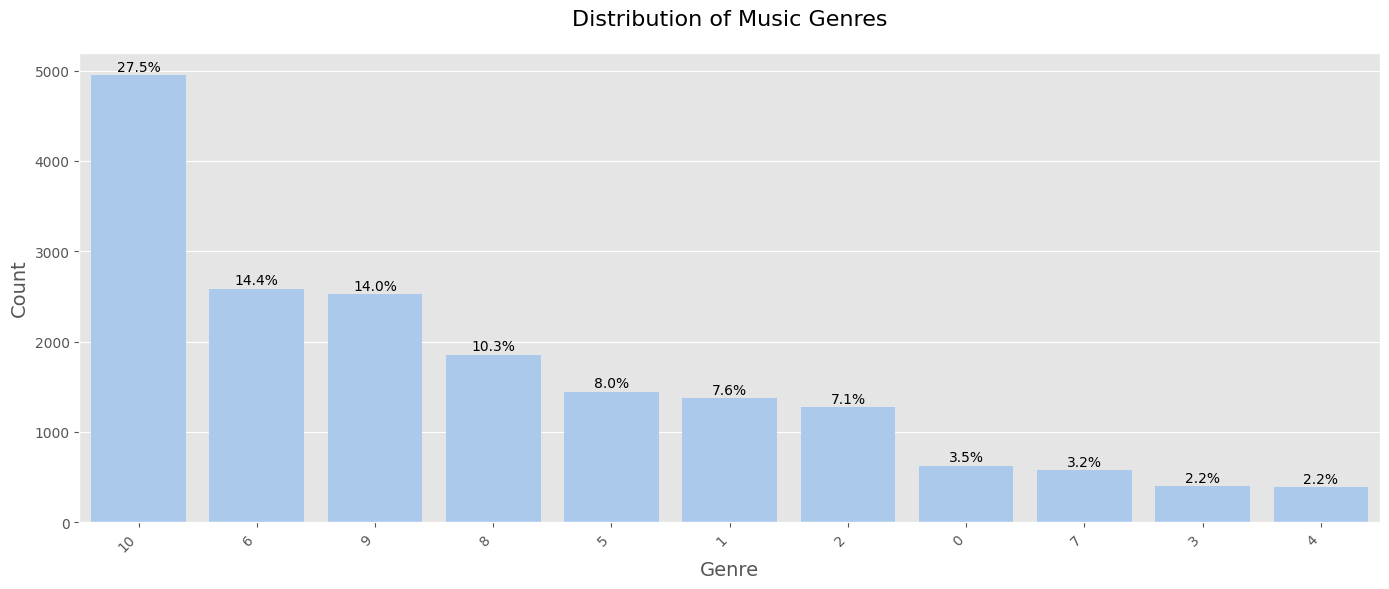

In [15]:
print("\n=== Starting Exploratory Data Analysis ===")

# 5.1 Genre Distribution
plt.figure(figsize=(14,6))
ax = sns.countplot(data=train_df, x='Class', order=train_df['Class'].value_counts().index)

plt.title('Distribution of Music Genres', fontsize=16, pad=20)
plt.xlabel('Genre', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45, ha='right')

# Add percentage labels
total = len(train_df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 50,
            f'{height/total:.1%}',
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()



=== Feature Distributions ===


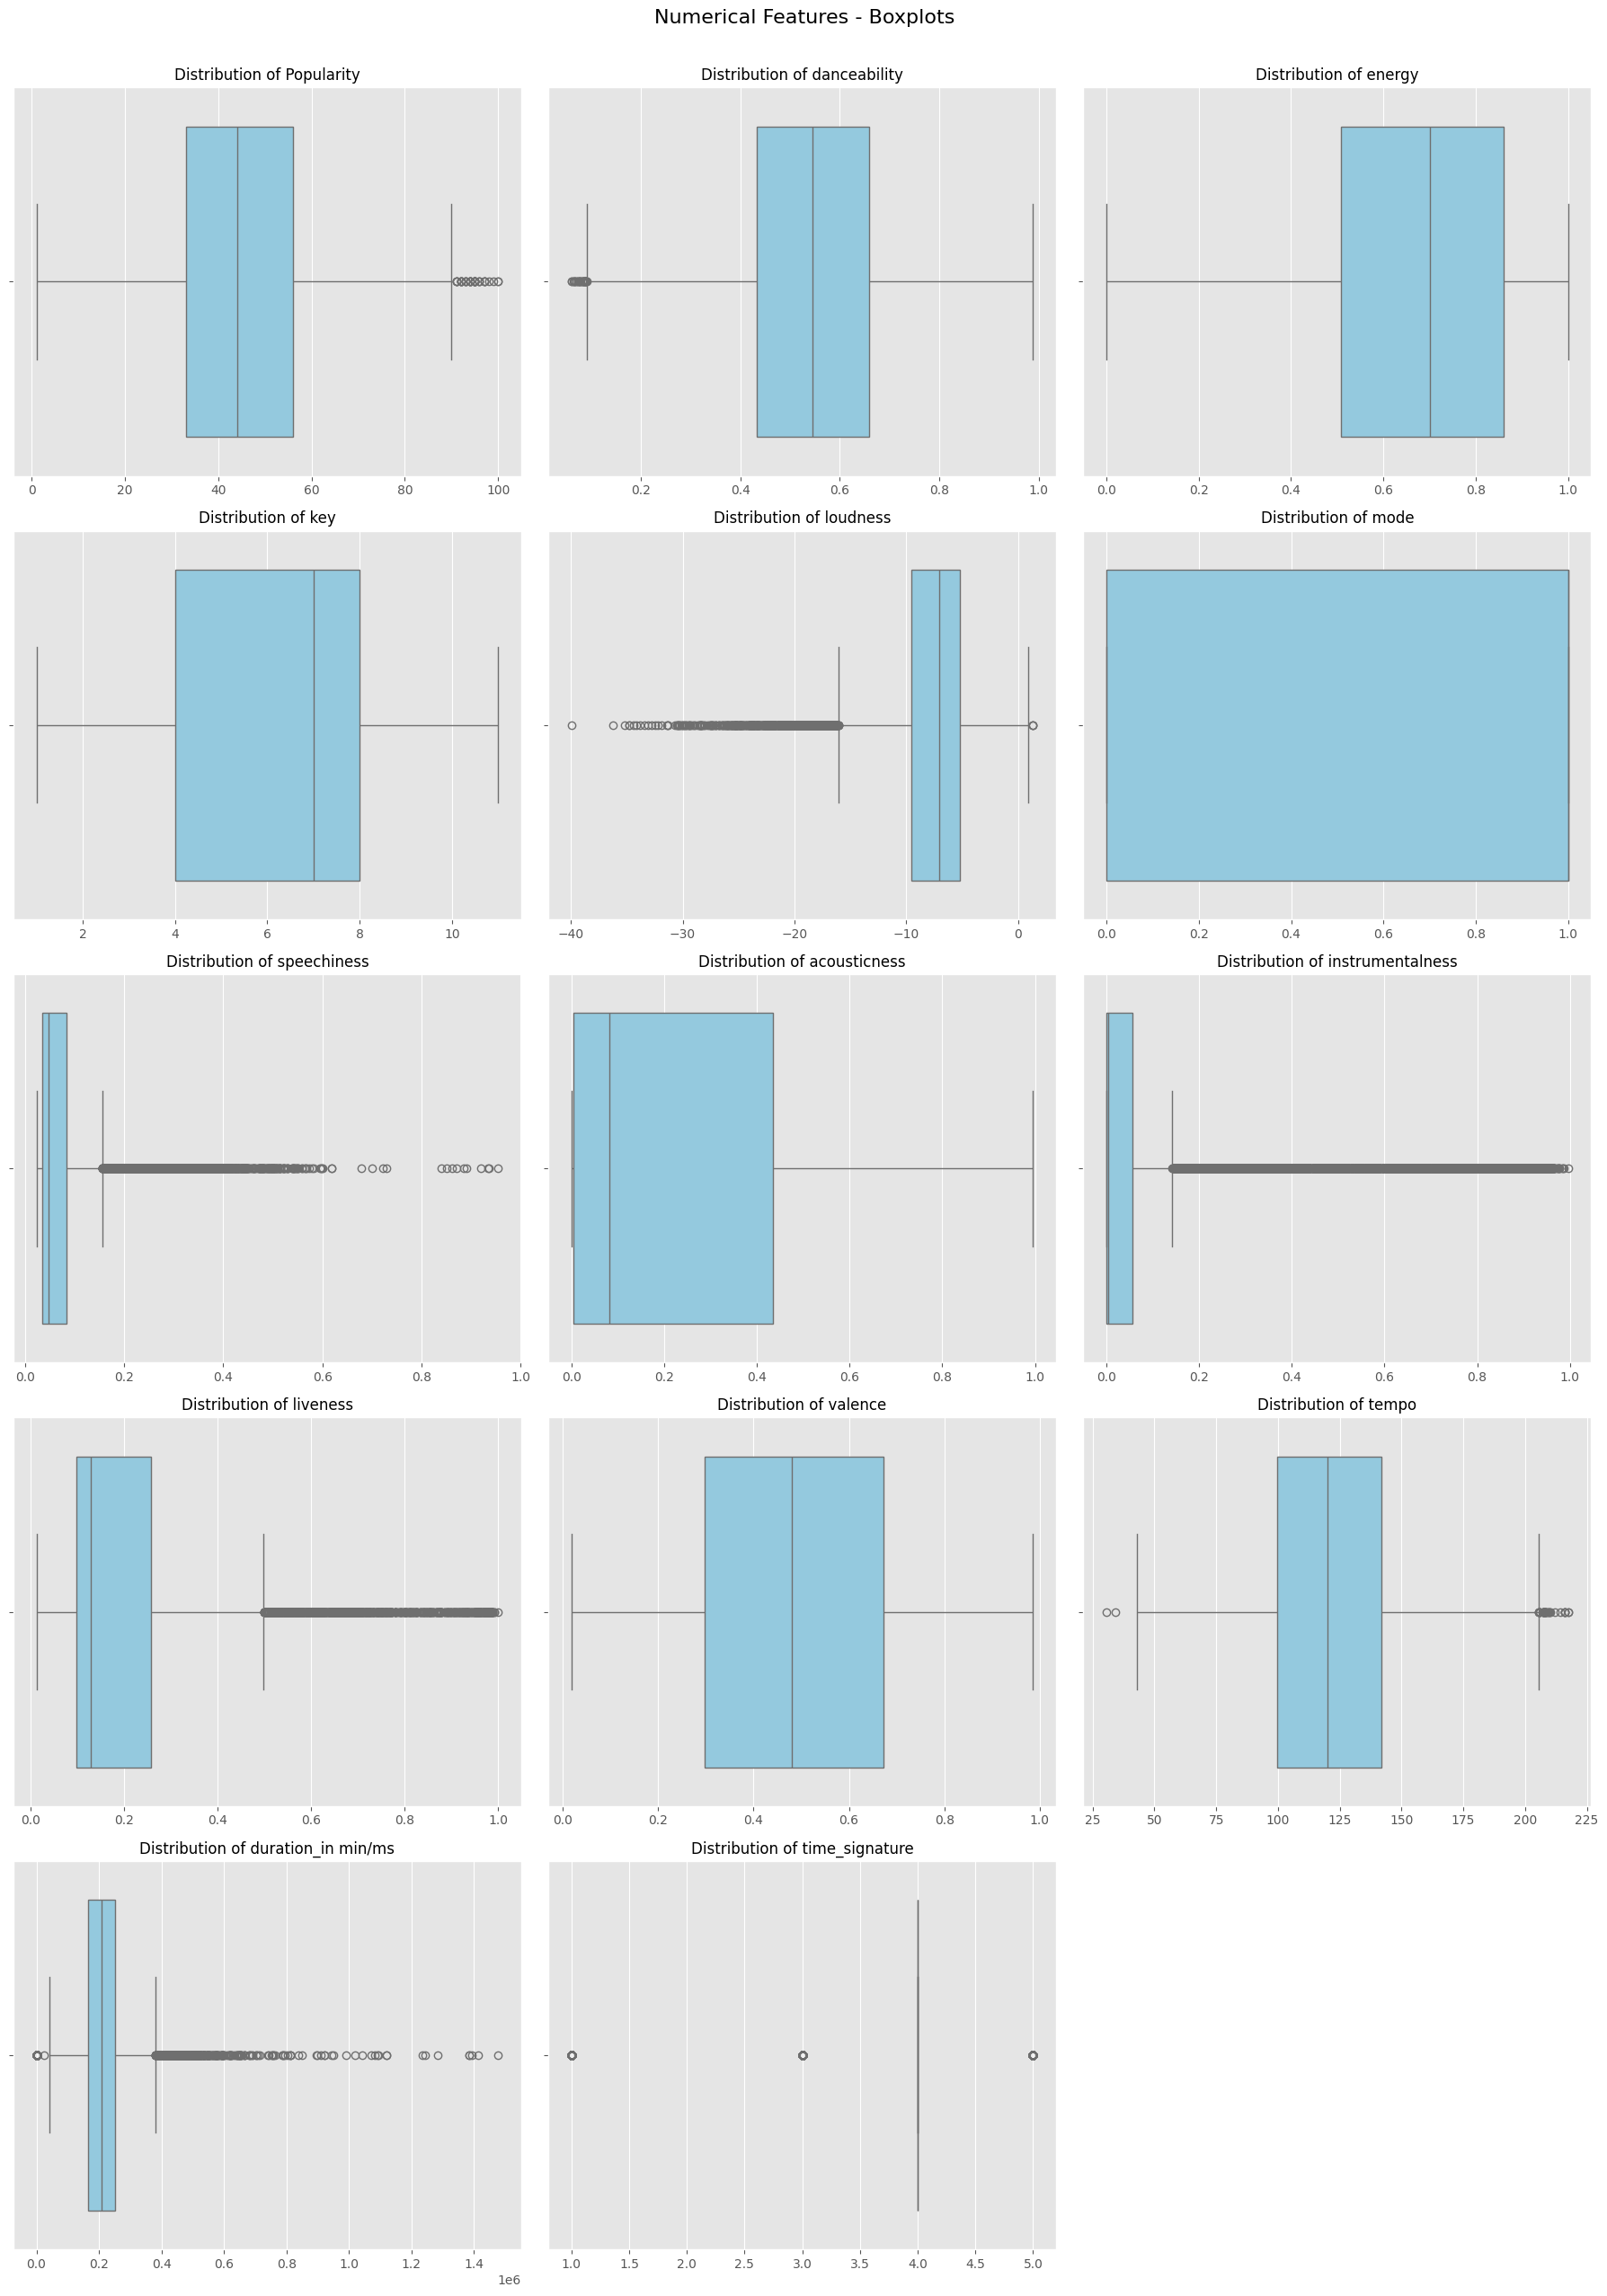

In [16]:
# 5.2 Feature Distributions
print("\n=== Feature Distributions ===")

# Create subplots for numerical features
n_cols = 3
n_rows = int(np.ceil(len(numerical_features) / n_cols))

# Boxplots
plt.figure(figsize=(18, 5*n_rows))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=train_df[col], color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('')
plt.tight_layout()
plt.suptitle('Numerical Features - Boxplots', y=1.02, fontsize=16)
plt.show()


In [17]:
# for col in ['speechiness', 'acousticness', 'instrumentalness']:
#     train_df[col] = np.log1p(train_df[col])
#     test_df[col] = np.log1p(test_df[col])

In [18]:
def replace_outliers_with_median(df, features, verbose=True):
    modified_df = df.copy()
    for col in features:
        if col in modified_df.columns:
            Q1 = modified_df[col].quantile(0.25)
            Q3 = modified_df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            median_val = modified_df[col].median()
            
            outliers = (modified_df[col] < lower_bound) | (modified_df[col] > upper_bound)
            if verbose:
                print(f"Replacing {outliers.sum()} outliers in '{col}' with median")
            modified_df.loc[outliers, col] = median_val
    return modified_df

# Exclude key/mode/time_signature

features_to_clean = [f for f in numerical_features if f not in ['key', 'time_signature', 'mode']]

print("Before outlier replacement:", train_df.shape[0])
train_df = replace_outliers_with_median(train_df, features_to_clean)
print("After outlier replacement:", train_df.shape[0])  # Shape won't change


Before outlier replacement: 17996
Replacing 41 outliers in 'Popularity' with median
Replacing 31 outliers in 'danceability' with median
Replacing 0 outliers in 'energy' with median
Replacing 818 outliers in 'loudness' with median
Replacing 2034 outliers in 'speechiness' with median
Replacing 0 outliers in 'acousticness' with median
Replacing 3714 outliers in 'instrumentalness' with median
Replacing 956 outliers in 'liveness' with median
Replacing 0 outliers in 'valence' with median
Replacing 36 outliers in 'tempo' with median
Replacing 3245 outliers in 'duration_in min/ms' with median
After outlier replacement: 17996



=== Feature Distributions ===


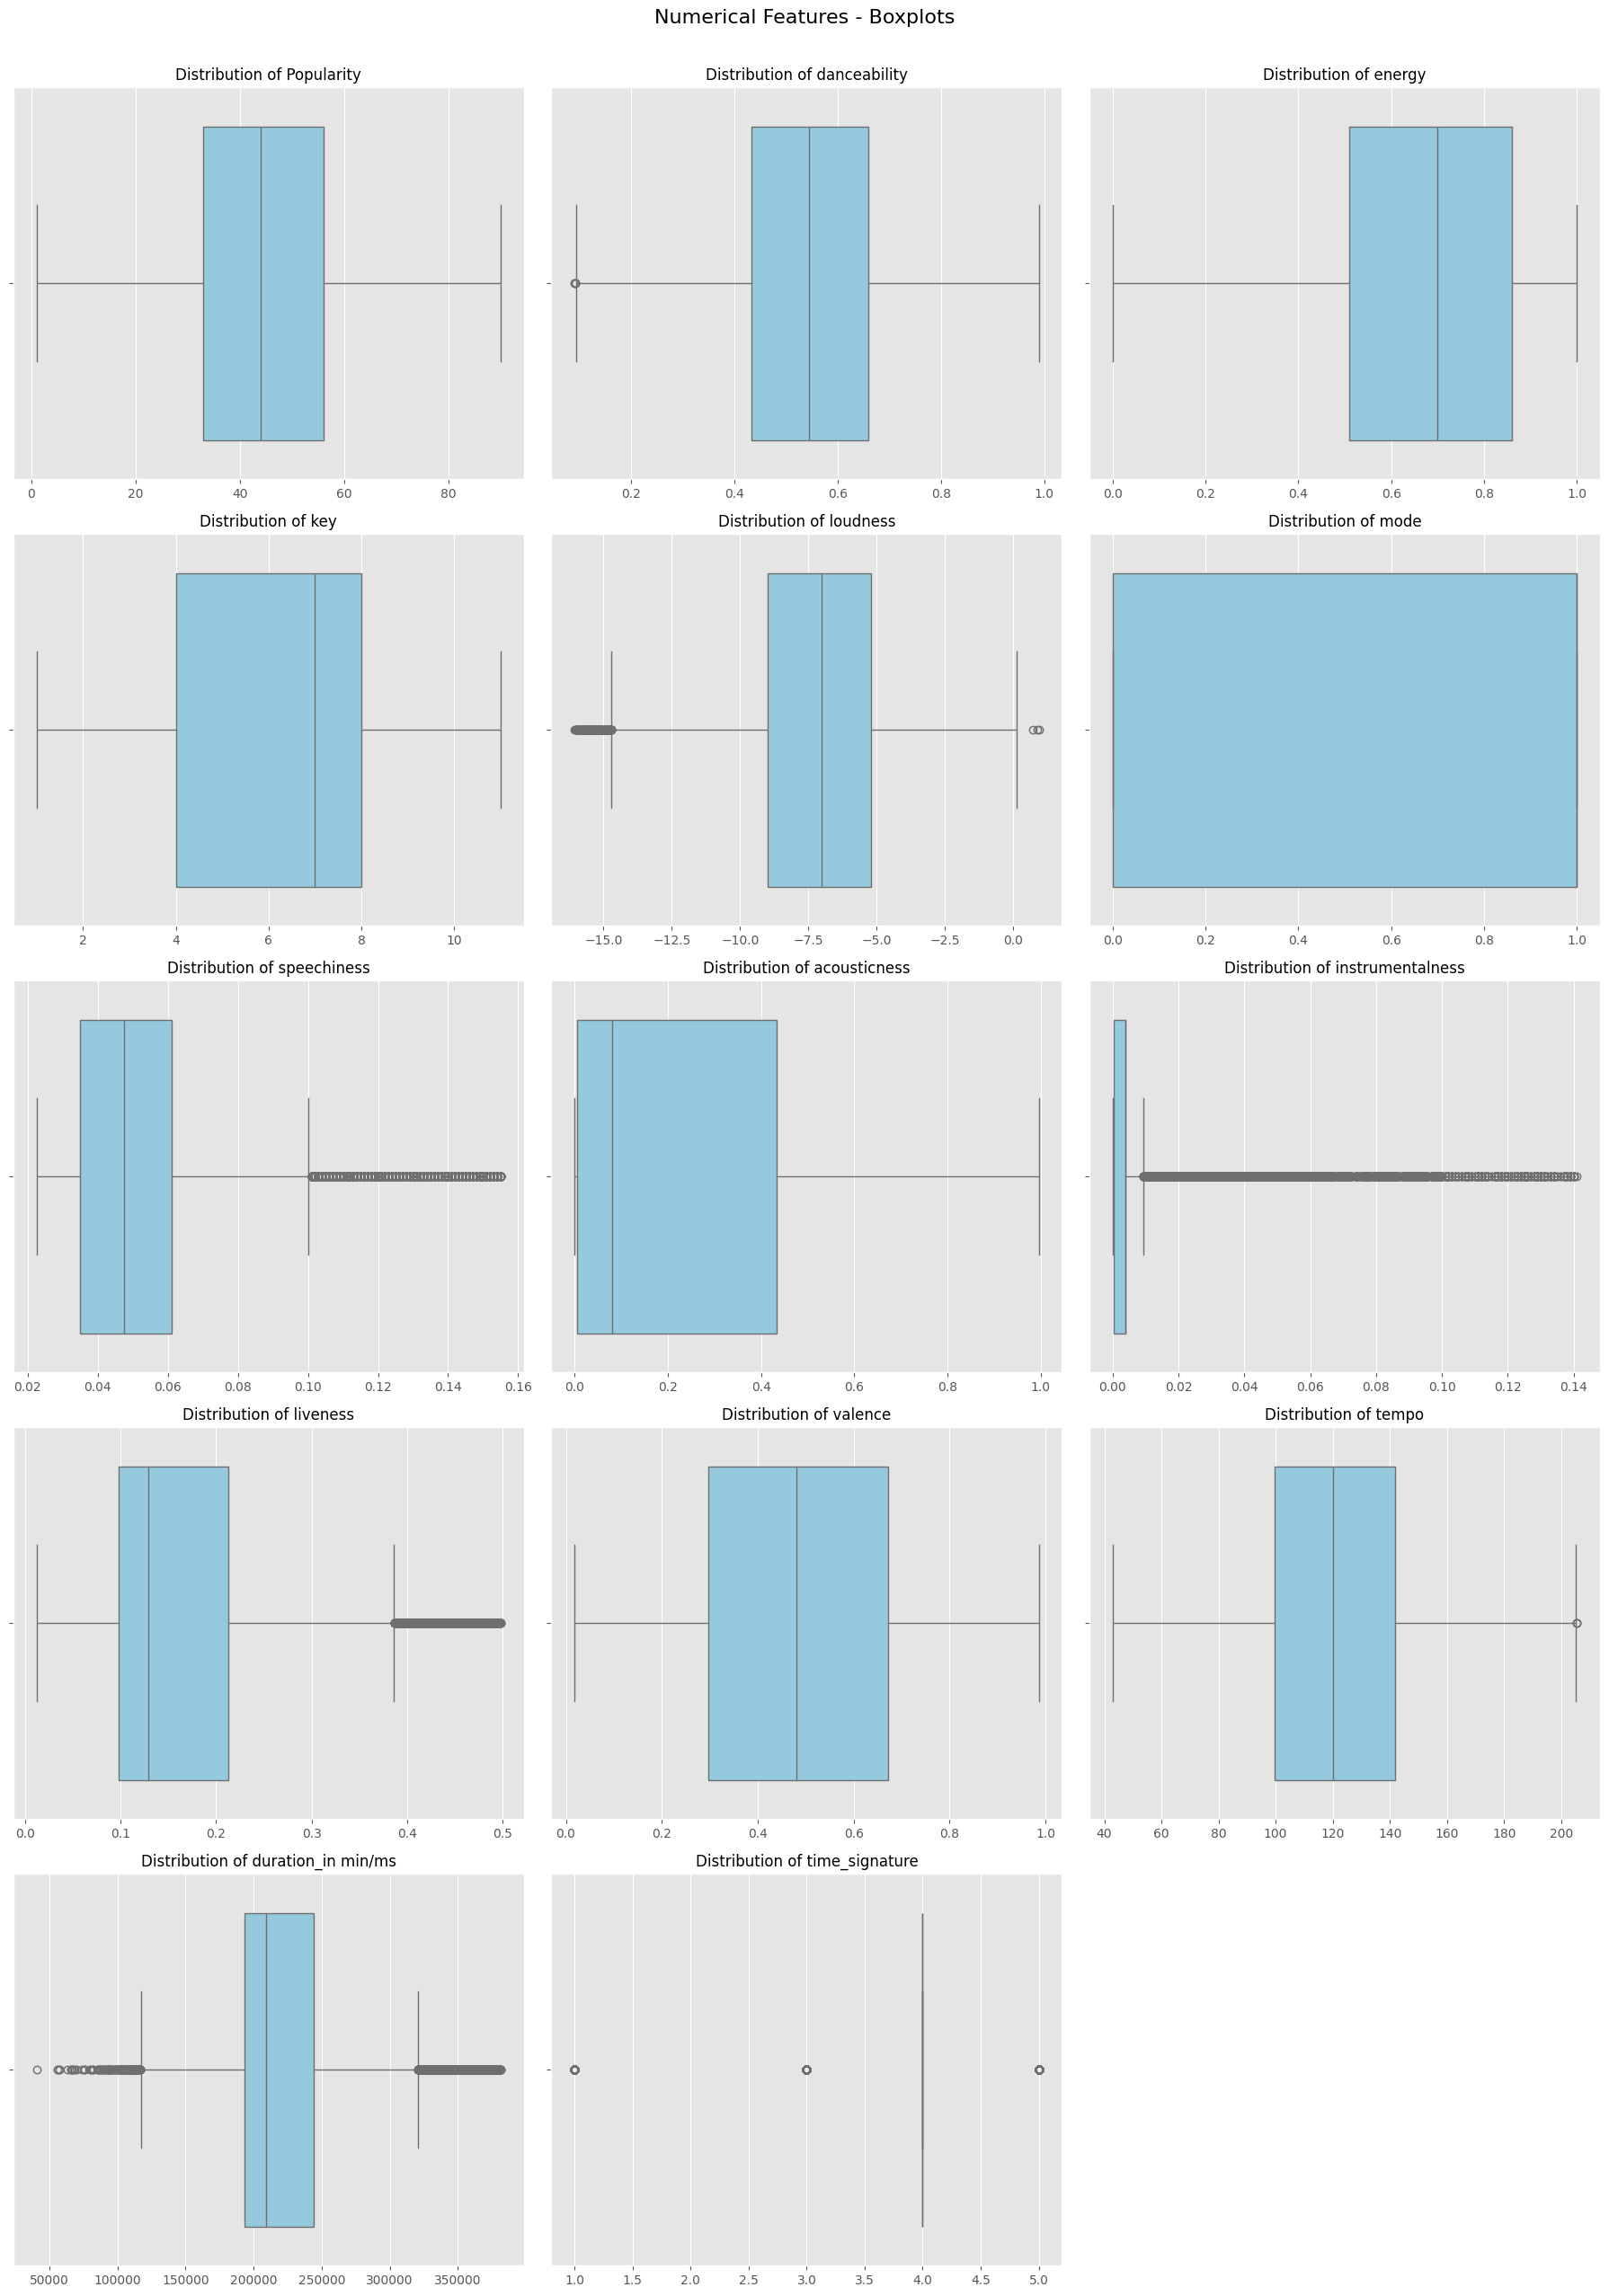

In [19]:
# 5.2 Feature Distributions
print("\n=== Feature Distributions ===")

# Create subplots for numerical features
n_cols = 3
n_rows = int(np.ceil(len(numerical_features) / n_cols))

# Boxplots
plt.figure(figsize=(18, 5*n_rows))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=train_df[col], color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('')
plt.tight_layout()
plt.suptitle('Numerical Features - Boxplots', y=1.02, fontsize=16)
plt.show()


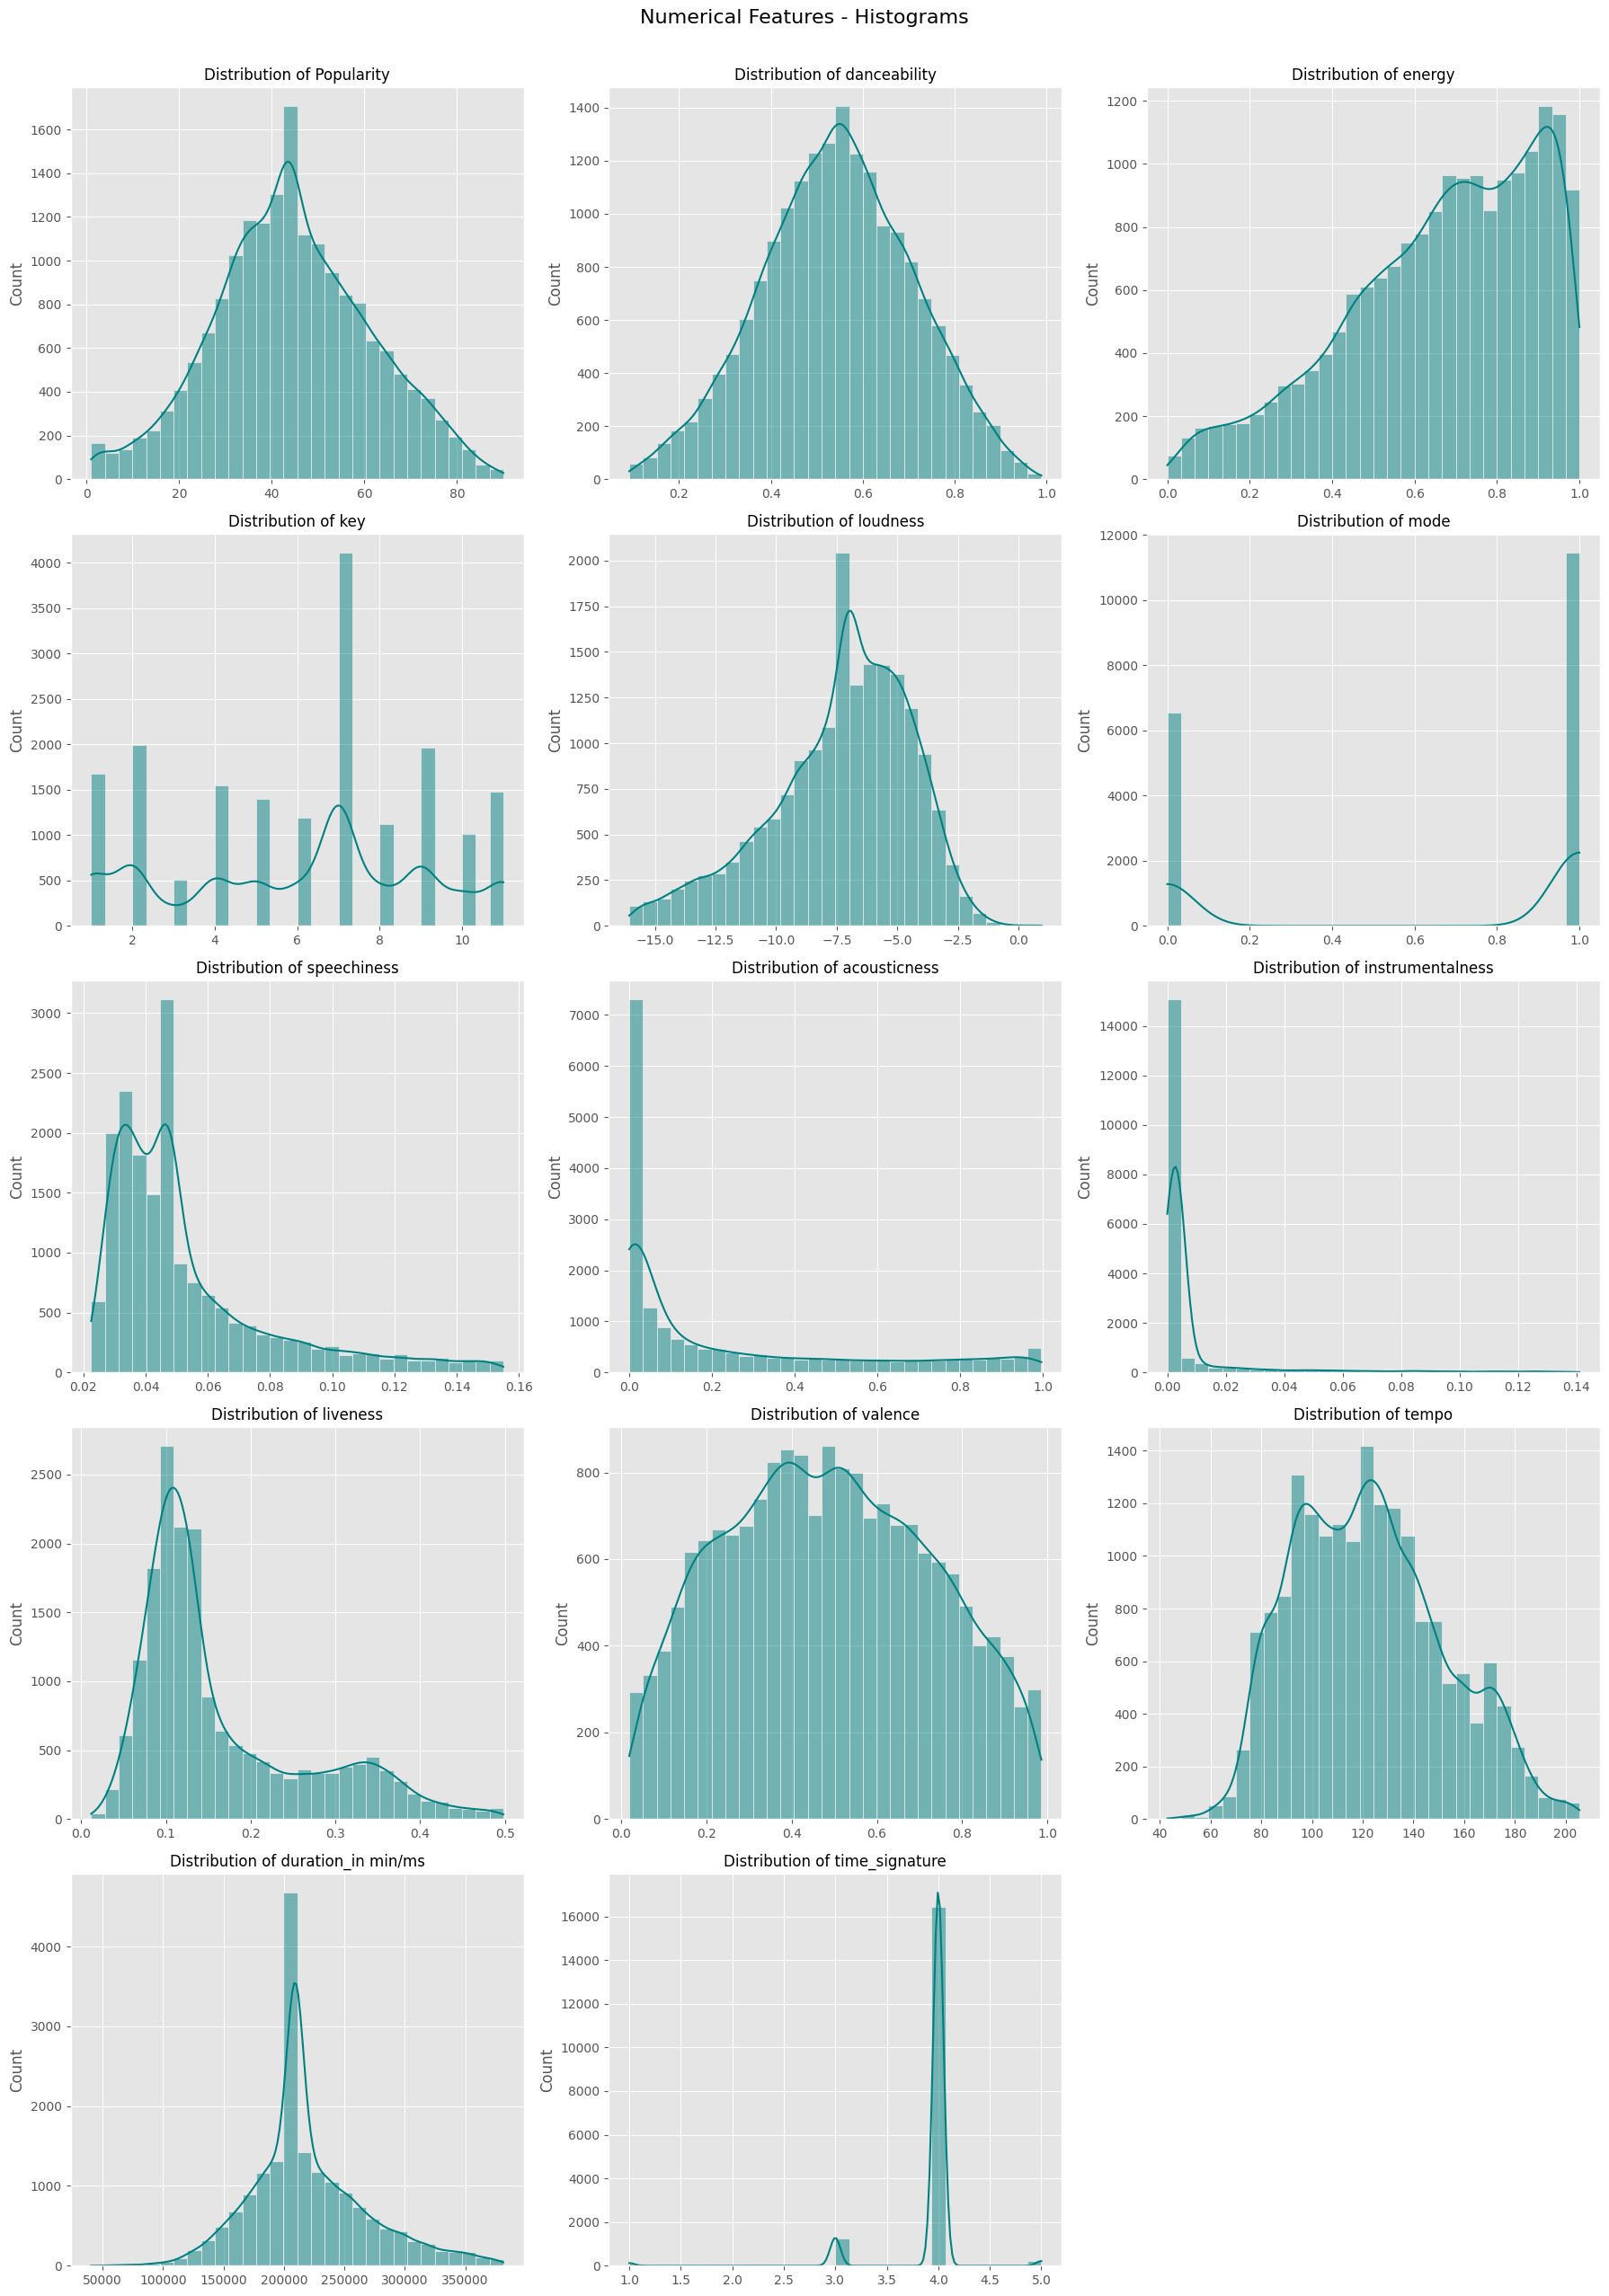

In [20]:
# Histograms
plt.figure(figsize=(18, 5*n_rows))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(train_df[col], bins=30, kde=True, color='teal')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('')
plt.tight_layout()
plt.suptitle('Numerical Features - Histograms', y=1.02, fontsize=16)
plt.show()


In [21]:
from sklearn.preprocessing import StandardScaler

print("\n=== Normalizing Numerical Features ===")
scaler = StandardScaler()
train_df[required_col] = scaler.fit_transform(train_df[required_col])
test_df[required_col] = scaler.transform(test_df[required_col])

print("Normalization completed")


=== Normalizing Numerical Features ===
Normalization completed



=== Correlation Analysis ===


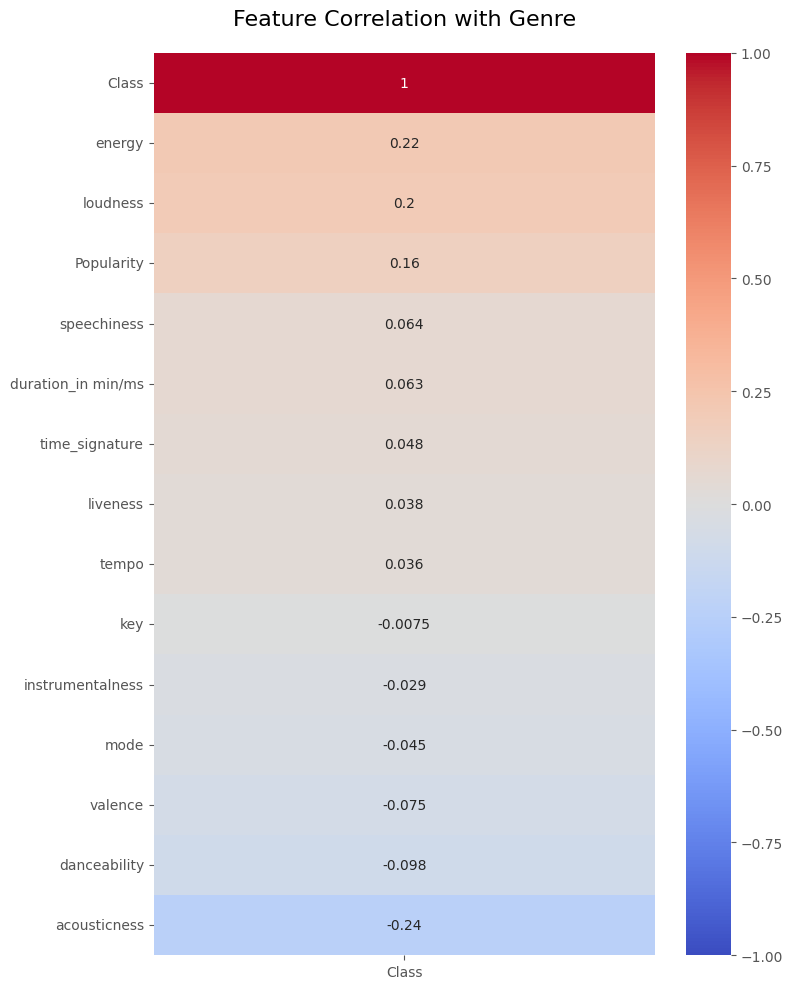

                    Popularity  danceability    energy       key  loudness  \
Popularity            1.000000      0.159396  0.052119  0.003918  0.110516   
danceability          0.159396      1.000000 -0.100406  0.005628 -0.078529   
energy                0.052119     -0.100406  1.000000  0.011090  0.606906   
key                   0.003918      0.005628  0.011090  1.000000  0.000231   
loudness              0.110516     -0.078529  0.606906  0.000231  1.000000   
mode                  0.015862     -0.066560 -0.035880 -0.094606 -0.048236   
speechiness          -0.005239     -0.045157  0.312399 -0.000706  0.204801   
acousticness         -0.125026      0.013703 -0.745963 -0.006544 -0.450791   
instrumentalness     -0.034778     -0.041123  0.023410 -0.018207 -0.038499   
liveness             -0.037913     -0.094771  0.205768 -0.001072  0.132709   
valence               0.053331      0.439292  0.222998  0.031422  0.044203   
tempo                -0.005094     -0.184762  0.212723  0.013450

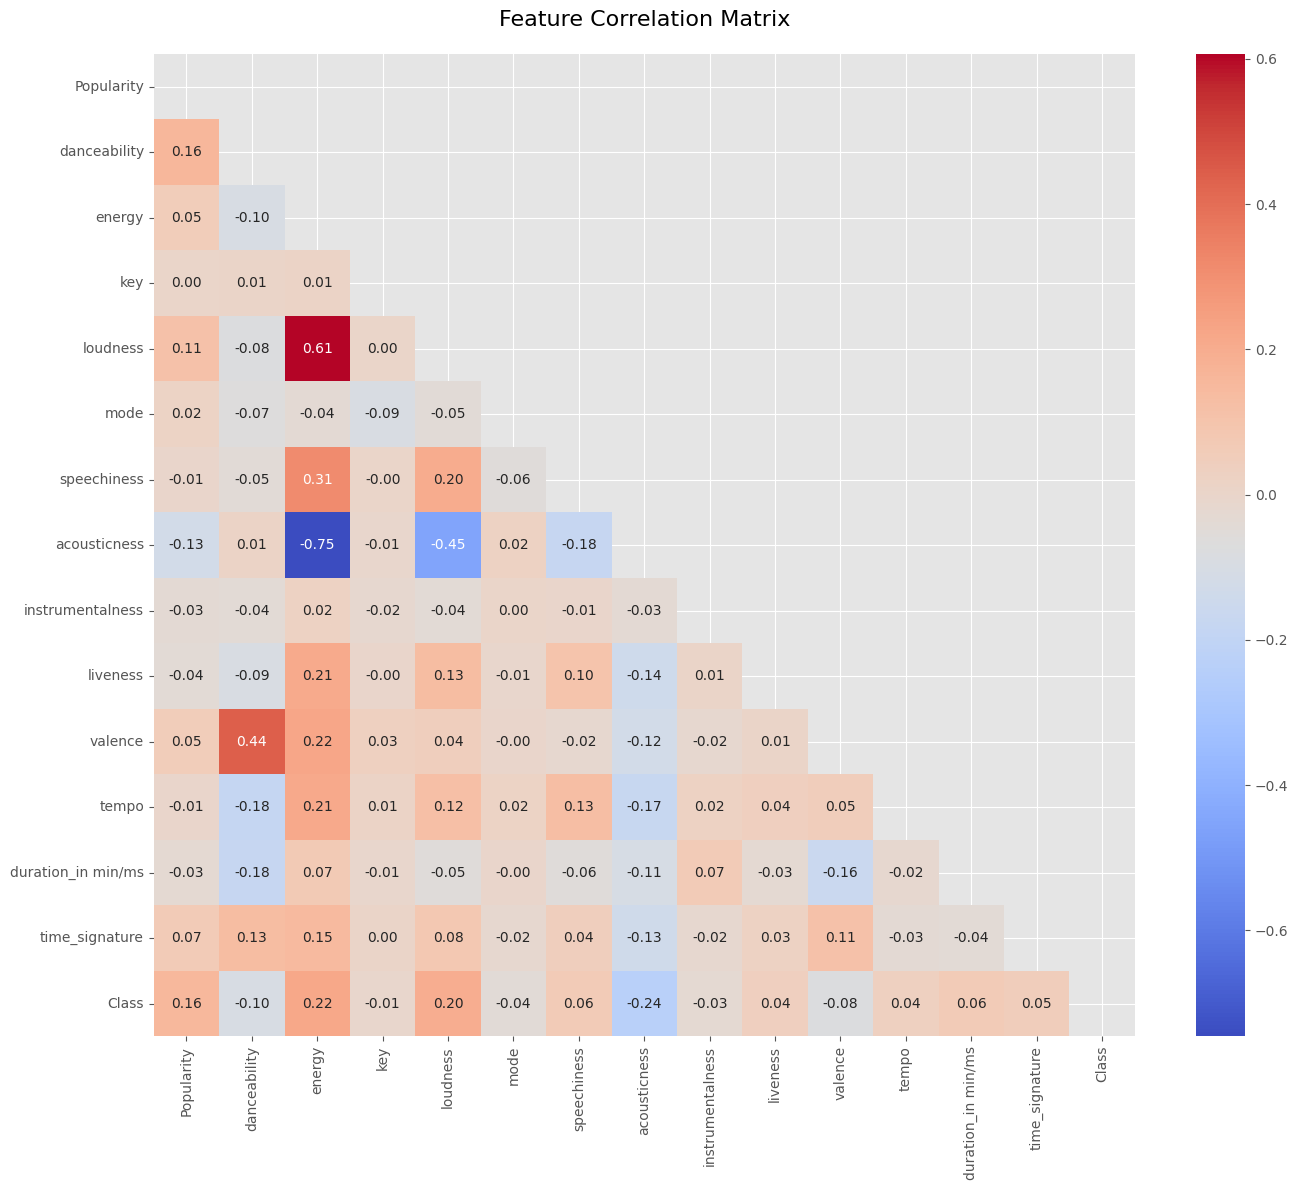

In [22]:
# 5.3 Correlation Analysis
print("\n=== Correlation Analysis ===")

# Correlation with target
corr_with_target = train_df[numerical_features + ['Class']].corr()[['Class']].sort_values('Class', ascending=False)

plt.figure(figsize=(8,10))
sns.heatmap(corr_with_target, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation with Genre', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Full correlation matrix
plt.figure(figsize=(14,12))
corr_matrix = train_df[numerical_features + ['Class']].corr()
print(corr_matrix)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()



=== Feature Relationships by Genre ===


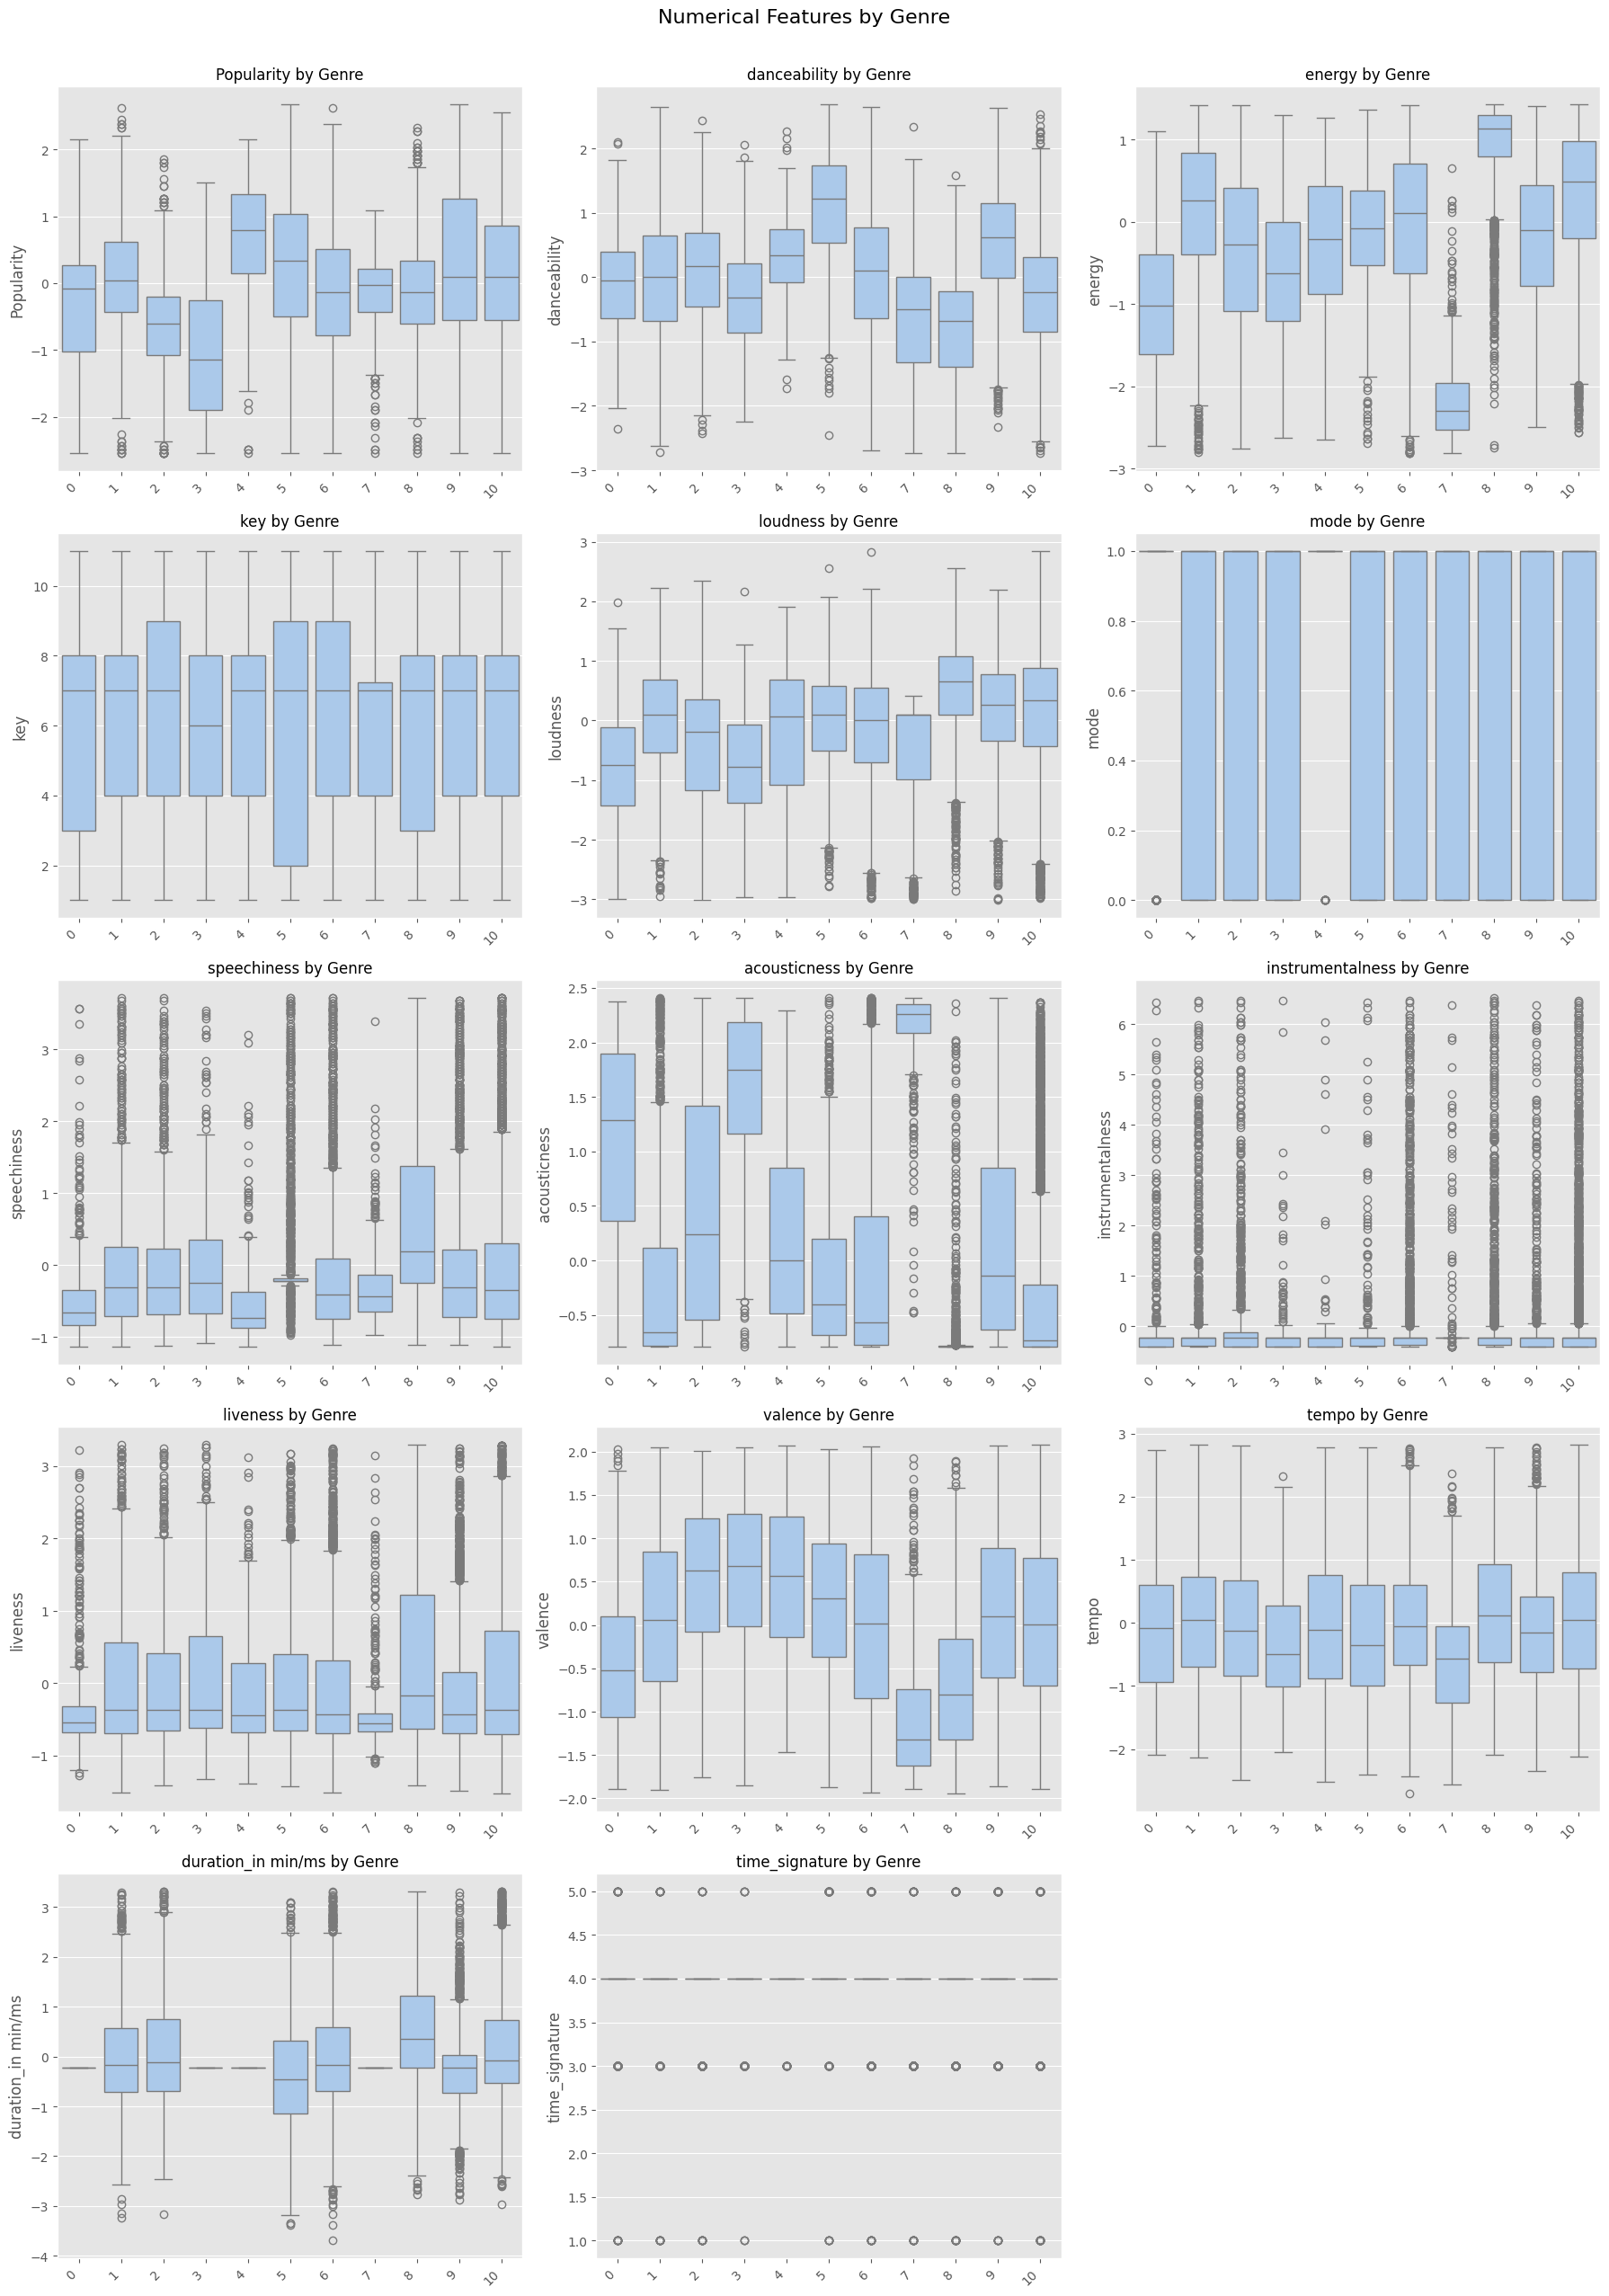

In [23]:
# 5.4 Feature Relationships by Genre
print("\n=== Feature Relationships by Genre ===")

plt.figure(figsize=(18, 5*n_rows))
for i, col in enumerate(numerical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x='Class', y=col, data=train_df)
    plt.title(f'{col} by Genre', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('')
plt.tight_layout()
plt.suptitle('Numerical Features by Genre', y=1.02, fontsize=16)
plt.show()


=== Pairplot of Key Features ===


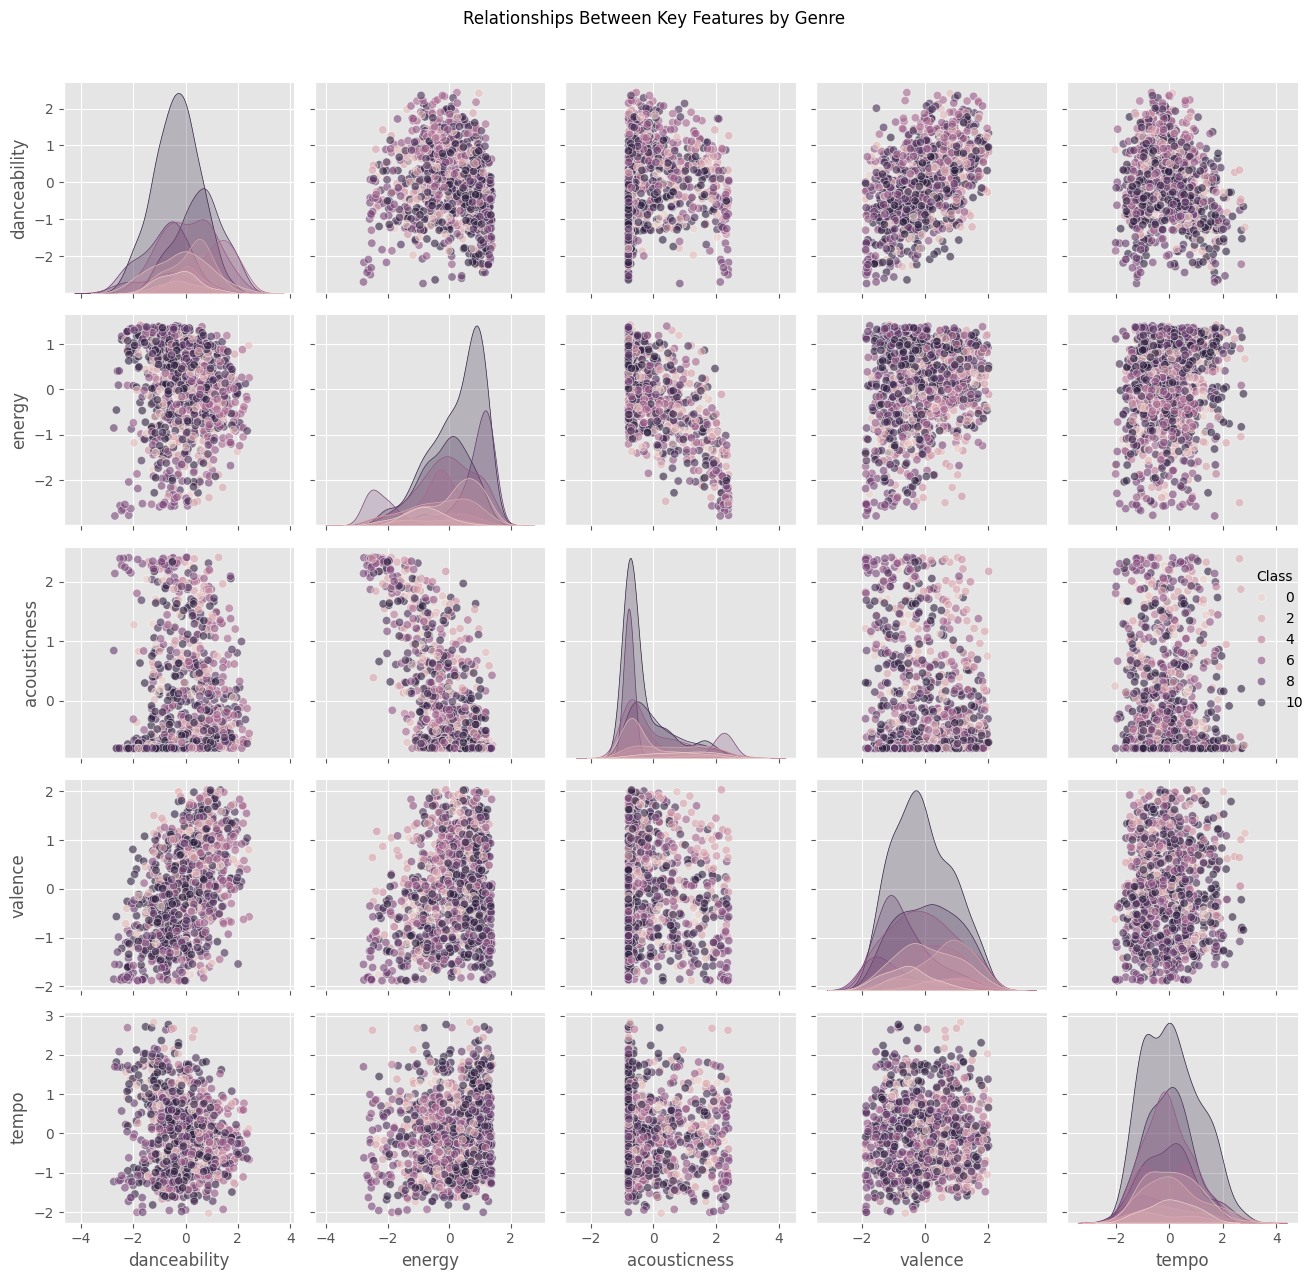

In [24]:
# 5.5 Pairplot of Key Features
print("\n=== Pairplot of Key Features ===")

# Select important features based on correlation
key_features = ['danceability', 'energy', 'acousticness', 'valence', 'tempo', 'Class']
key_features = [f for f in key_features if f in train_df.columns]

# Sample data if large
plot_data = train_df.sample(1000) if len(train_df) > 1000 else train_df

sns.pairplot(plot_data[key_features], hue='Class', diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle('Relationships Between Key Features by Genre', y=1.02)
plt.tight_layout()
plt.show()


In [25]:
train_df['key'].value_counts()

key
7.0     4111
2.0     1994
9.0     1961
1.0     1680
4.0     1549
11.0    1476
5.0     1397
6.0     1190
8.0     1119
10.0    1010
3.0      509
Name: count, dtype: int64

In [26]:
train_df['time_signature'].value_counts()

time_signature
4    16451
3     1228
5      203
1      114
Name: count, dtype: int64

In [27]:
train_df['mode'].value_counts()

mode
1    11459
0     6537
Name: count, dtype: int64